<a href="https://colab.research.google.com/github/iisratislam/Generative_Modeling_Case-Study/blob/main/part1_architecture_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN Case Study — Part 1, Task 3: Architecture Comparison

We investigate how **generator depth** affects the quality of generated
samples. Keeping the WGAN-GP training procedure fixed, we compare:

- a **shallow** generator (1 hidden layer), and
- a **deep** generator (3 hidden layers),

on the same 2D spiral target. Depth controls the network's capacity to
represent highly non-linear manifolds, so we expect the deeper generator to
trace the spiral more faithfully.

In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import copy

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 1. Real data: the 2D spiral

Same spiral target as Task 2 — points sampled in polar form, converted to
Cartesian, with small Gaussian noise for thickness.

In [2]:
def sample_real_spiral_data(n_samples, n_turns=3, noise=0.05):
    """
    Generate real samples from a 2D spiral.

    Radius grows linearly with angle; (r, theta) converted to (x, y).
    sqrt(uniform) spreads points evenly along the spiral; Gaussian noise
    adds thickness. Returns a tensor of shape (n_samples, 2).
    """
    theta = np.sqrt(np.random.uniform(0, 1, n_samples)) * (2 * np.pi * n_turns)
    r = theta / (2 * np.pi * n_turns)

    x = r * np.cos(theta) + noise * np.random.randn(n_samples)
    y = r * np.sin(theta) + noise * np.random.randn(n_samples)

    data = np.stack([x, y], axis=1).astype(np.float32)
    return torch.from_numpy(data)

## 2. A configurable Generator

We define a Generator whose **number of hidden layers** is a parameter
(`n_hidden_layers`). This lets us build shallow and deep variants from the
same class, changing only depth while keeping everything else identical — a
clean single-variable experiment. The Critic is the same WGAN-GP critic as
before.

In [3]:
class ConfigurableGenerator(nn.Module):
    """
    Generator with a configurable number of hidden layers.

    Args:
        noise_dim:        size of the input noise vector
        hidden_dim:       width of each hidden layer
        out_dim:          output dimension (2 for our 2D points)
        n_hidden_layers:  how many hidden layers to stack (controls depth)
    """
    def __init__(self, noise_dim=16, hidden_dim=128, out_dim=2, n_hidden_layers=3):
        super().__init__()

        layers = [nn.Linear(noise_dim, hidden_dim), nn.ReLU()]
        # Add (n_hidden_layers - 1) more hidden layers
        for _ in range(n_hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
        layers += [nn.Linear(hidden_dim, out_dim)]

        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


class Critic(nn.Module):
    """WGAN critic: outputs a real-valued score (no sigmoid)."""
    def __init__(self, in_dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

## 3. WGAN-GP training (same procedure as Task 2)

We reuse the WGAN-GP setup: gradient penalty for the Lipschitz constraint,
critic trained `n_critic` times per generator step, and best-coverage
checkpointing so we keep the best generator state seen during training.

In [4]:
def gradient_penalty(critic, real_data, fake_data):
    """WGAN-GP gradient penalty (pushes critic gradient norm toward 1)."""
    batch_size = real_data.size(0)
    epsilon = torch.rand(batch_size, 1, device=device)
    interpolated = epsilon * real_data + (1 - epsilon) * fake_data
    interpolated.requires_grad_(True)

    scores = critic(interpolated)
    gradients = torch.autograd.grad(
        outputs=scores, inputs=interpolated,
        grad_outputs=torch.ones_like(scores),
        create_graph=True, retain_graph=True
    )[0]
    grad_norm = gradients.norm(2, dim=1)
    return ((grad_norm - 1) ** 2).mean()


def coverage_score(generator, sample_real_fn, noise_dim, n=1000):
    """
    Average nearest-neighbour distance from real points to generated points.
    Lower = generated samples cover the real distribution better.
    Used to checkpoint the best generator during training.
    """
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n, noise_dim, device=device)
        fake = generator(z).cpu()
    real = sample_real_fn(n)
    dists = torch.cdist(real, fake)
    nn_dist = dists.min(dim=1).values.mean()
    generator.train()
    return nn_dist.item()


def train_wgan_gp(generator, critic, sample_real_fn, noise_dim=16,
                  n_epochs=4000, batch_size=256, lr=1e-4,
                  n_critic=2, lambda_gp=10.0, log_every=1000):
    """
    Trains a WGAN-GP, keeping the best-covering generator state.
    Returns loss histories and the best generator state_dict.
    """
    generator.to(device); critic.to(device)

    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.0, 0.9))
    opt_c = torch.optim.Adam(critic.parameters(), lr=lr, betas=(0.0, 0.9))

    g_losses, c_losses = [], []
    best_score = float("inf")
    best_state = copy.deepcopy(generator.state_dict())

    for epoch in range(n_epochs):
        for _ in range(n_critic):
            real_data = sample_real_fn(batch_size).to(device)
            z = torch.randn(batch_size, noise_dim, device=device)
            fake_data = generator(z).detach()

            c_loss = -(critic(real_data).mean() - critic(fake_data).mean()) \
                     + lambda_gp * gradient_penalty(critic, real_data, fake_data)

            opt_c.zero_grad(); c_loss.backward(); opt_c.step()

        z = torch.randn(batch_size, noise_dim, device=device)
        g_loss = -critic(generator(z)).mean()
        opt_g.zero_grad(); g_loss.backward(); opt_g.step()

        g_losses.append(g_loss.item()); c_losses.append(c_loss.item())

        if epoch % 100 == 0:
            score = coverage_score(generator, sample_real_fn, noise_dim)
            if score < best_score:
                best_score = score
                best_state = copy.deepcopy(generator.state_dict())

        if (epoch + 1) % log_every == 0:
            print(f"Epoch {epoch+1}/{n_epochs} | Critic: {c_loss.item():.4f} "
                  f"| G: {g_loss.item():.4f} | best coverage: {best_score:.4f}")

    return g_losses, c_losses, best_state

## 4. Train the shallow generator (1 hidden layer)

First we train the shallow variant. With only one hidden layer, the generator
has limited capacity to represent the spiral's tight, multi-turn structure.

In [5]:
NOISE_DIM = 16

# Shallow generator: only 1 hidden layer
torch.manual_seed(0)
gen_shallow = ConfigurableGenerator(noise_dim=NOISE_DIM, hidden_dim=128,
                                    out_dim=2, n_hidden_layers=1)
critic_shallow = Critic(in_dim=2, hidden_dim=128)

g_losses_shallow, c_losses_shallow, best_state_shallow = train_wgan_gp(
    gen_shallow, critic_shallow, sample_real_spiral_data,
    noise_dim=NOISE_DIM, n_epochs=4000, lr=1e-4, n_critic=2
)

# Load the best-covering state before evaluating
gen_shallow.load_state_dict(best_state_shallow)
print("Shallow generator training complete.")

Epoch 1000/4000 | Critic: 0.1229 | G: -1.4995 | best coverage: 0.0340
Epoch 2000/4000 | Critic: -0.6963 | G: -0.0697 | best coverage: 0.0340
Epoch 3000/4000 | Critic: 0.3115 | G: -0.8463 | best coverage: 0.0340
Epoch 4000/4000 | Critic: 0.6009 | G: -2.2973 | best coverage: 0.0340
Shallow generator training complete.


## 5. Train the deep generator (3 hidden layers)

Now the deep variant. With three hidden layers, the generator has far more
capacity to bend the noise distribution into the spiral's tight, multi-turn
shape. Everything else (training procedure, width, noise dimension) is
identical — only the depth changes.

In [6]:
# Deep generator: 3 hidden layers
torch.manual_seed(42)   # different seed — previous run (seed 0) was unstable
gen_deep = ConfigurableGenerator(noise_dim=NOISE_DIM, hidden_dim=128,
                                 out_dim=2, n_hidden_layers=3)
critic_deep = Critic(in_dim=2, hidden_dim=128)

g_losses_deep, c_losses_deep, best_state_deep = train_wgan_gp(
    gen_deep, critic_deep, sample_real_spiral_data,
    noise_dim=NOISE_DIM, n_epochs=4000, lr=1e-4, n_critic=2
)

gen_deep.load_state_dict(best_state_deep)
print("Deep generator training complete.")

Epoch 1000/4000 | Critic: 0.1543 | G: -1.2102 | best coverage: 0.3000
Epoch 2000/4000 | Critic: 0.1511 | G: -1.3320 | best coverage: 0.3000
Epoch 3000/4000 | Critic: 0.2007 | G: 0.1333 | best coverage: 0.2902
Epoch 4000/4000 | Critic: 0.0491 | G: 0.0822 | best coverage: 0.2902
Deep generator training complete.


## 6. Compare shallow vs deep generators

We plot the generated samples from both generators side by side against the
real spiral, and report each model's best coverage score (average
nearest-neighbour distance from real to generated points; lower is better).

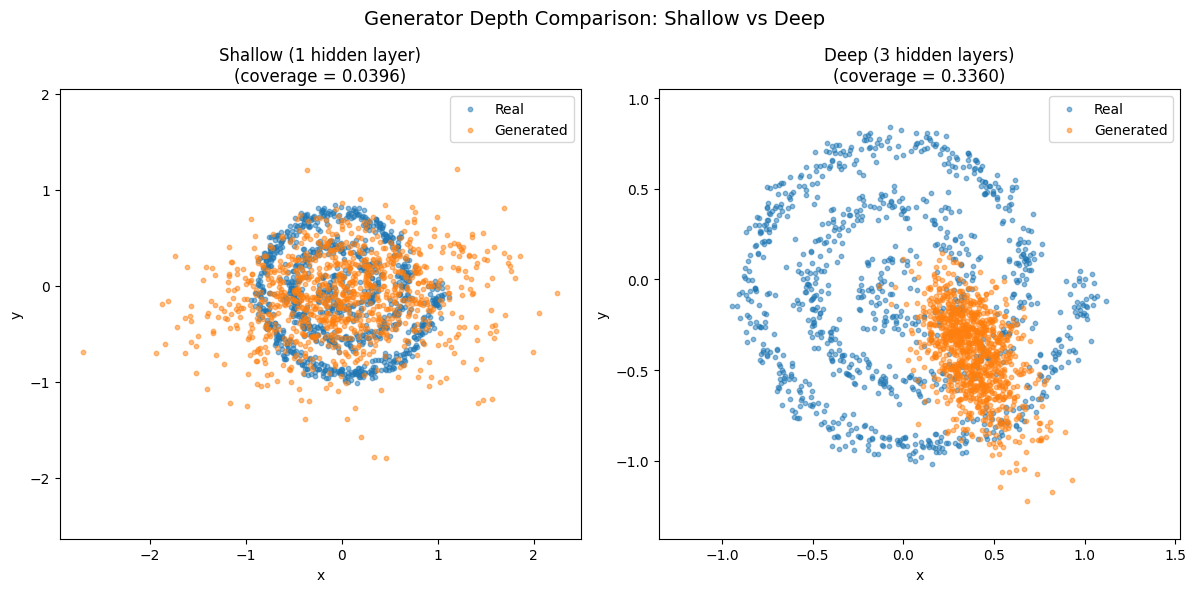

In [7]:
def plot_comparison(gen_a, label_a, score_a,
                    gen_b, label_b, score_b,
                    sample_real_fn, noise_dim, n_samples=1000):
    """
    Plots two generators' outputs side by side against the real spiral,
    with each model's coverage score in the subplot title.
    """
    real = sample_real_fn(n_samples).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for ax, gen, label, score in [
        (axes[0], gen_a, label_a, score_a),
        (axes[1], gen_b, label_b, score_b),
    ]:
        gen.eval()
        with torch.no_grad():
            z = torch.randn(n_samples, noise_dim, device=device)
            fake = gen(z).cpu().numpy()
        gen.train()

        ax.scatter(real[:, 0], real[:, 1], s=10, alpha=0.5, label="Real")
        ax.scatter(fake[:, 0], fake[:, 1], s=10, alpha=0.5, label="Generated")
        ax.set_title(f"{label}\n(coverage = {score:.4f})")
        ax.set_xlabel("x"); ax.set_ylabel("y")
        ax.axis("equal")
        ax.legend()

    plt.suptitle("Generator Depth Comparison: Shallow vs Deep", fontsize=14)
    plt.tight_layout()
    plt.show()


# Recompute each model's coverage score for display
score_shallow = coverage_score(gen_shallow, sample_real_spiral_data, NOISE_DIM)
score_deep = coverage_score(gen_deep, sample_real_spiral_data, NOISE_DIM)

plot_comparison(
    gen_shallow, "Shallow (1 hidden layer)", score_shallow,
    gen_deep, "Deep (3 hidden layers)", score_deep,
    sample_real_spiral_data, NOISE_DIM
)